---
* conda activate deep_learning_project-env
* conda deactivate
---



---

###  **General Pipeline Summary**

1. **Preprocessing & Caching**  
   Convert all audio files to **mel spectrograms** and cache them for fast access.

2. **Data Augmentation**  
   Use **SpecAugment-inspired techniques**: time stretching, frequency & time masking, and noise.

3. **Model Training (Main)**  
   - **K-Fold cross-validation** (5 folds)  
   - CNN with **Squeeze-and-Excite blocks**  
   - Hyperparameter tuning with **KerasTuner (Hyperband)**

4. **Binary Classifier** *(for class 5 vs 7)*  
   Separate model trained to fix confusion between class 5 and 7 using a focused binary dataset.

5. **Testing & Ensemble**  
   - All fold models predict on test set  
   - **Majority vote** for ensemble  
   - Patch ensemble results using **binary classifier** to improve class 5 predictions

6. **Evaluation**  
   Accuracy and classification reports are printed for all components.

---

# TODO :

## Areas for Improvement

1. **Code Organization**:
   - Some naming inconsistencies (e.g., *load*and_process instead of load_and_process)
   - Function definitions could be better grouped by purpose

2. **Binary Model Integration**:
   - While clever, the binary model approach creates two points of potential failure
   - It's unclear how you combine decisions between main and binary models

3. **Model Architecture**:
   - Consider experimenting with different main architectures (EfficientNet, MobileNetV3)
   - The channel dimensions (32→64→128) could be expanded for more expressivity

4. **Error Handling**:
   - Some error handling is present, but could be more systematic
   - Missing handling for potential failures in model ensemble phase

## Recommendations

1. **Ensemble Approach**:
   - Instead of a separate binary model, consider training multiple models with different architectures
   - Use soft voting (average probabilities) instead of hard voting for more nuanced predictions

2. **Feature Engineering**:
   - Try additional acoustic features like MFCCs, spectral contrast, or chroma features
   - Consider multi-input models that use different feature representations

3. **Advanced Techniques**:
   - Implement mixup or cutmix augmentation strategies
   - Add learning rate warmup at the beginning of training
   - Try focal loss instead of standard categorical cross-entropy

4. **Debugging Aid**:
   - Add confusion matrix visualization for each fold and ensemble
   - Implement T-SNE/UMAP visualization of embeddings to see class separation

5. **Binary Model Alternative**:
   - Instead of a separate binary model, consider a hierarchical classification approach
   - Or use a single model with a custom loss that penalizes class 5-7 confusion more heavily

---

### Middle-ground alternatives for ensemble:

1. **Lightweight architectural variations**: Instead of completely different architectures, try variations of your current CNN model with different depths, filter configurations, or attention mechanisms. This gives you architectural diversity without the full cost.

2. **Single architecture with different input features**: Train the same architecture on different input representations (mel spectrograms with different parameters, MFCCs, spectral contrast features, etc.).

3. **Snapshot ensembles**: Train a single model but save its weights at different points during training, especially after learning rate changes. This gives you model diversity at little extra cost.

4. **Two-architecture approach**: If you're concerned about the class 5 vs 7 issue, perhaps use your 5-fold ensemble for the main model and a single specialized model with a different architecture for the problematic classes.

For your specific situation, I'd recommend sticking with your K-fold approach for now since it's already working well, and only exploring multi-architecture ensembles if:

1. You have sufficient computational resources
2. You've exhausted other optimization strategies
3. The performance improvement is critical for your application

The 5-fold ensemble with a specialized binary classifier for classes 5 and 7 seems like a good balance of performance and practicality for your current needs.
---

In [1]:
!pip install -q numpy
!pip install -q pandas
!pip install -q librosa
!pip install -q tensorflow
!pip install -q scikit-learn
!pip install -q keras-tuner
!pip install -q tensorflow.keras.callbacks
!pip install -q tensorflow.keras


ERROR: Could not find a version that satisfies the requirement tensorflow.keras.callbacks (from versions: none)
ERROR: No matching distribution found for tensorflow.keras.callbacks


In [1]:
import os
import random
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
import keras_tuner as kt
from sklearn.model_selection import train_test_split


# Data & Audio settings
SR = 22050
N_MELS = 256
FMAX = 8000
FIXED_TIME_STEPS = 150
NUM_CLASSES = 10

# Training parameters
BATCH_SIZE = 32
EPOCHS = 50
N_FOLDS = 5
SEED = 42

# Paths
TRAIN_CSV_PATH = "dataset/Train.csv"
TRAIN_AUDIO_DIR = "dataset/Train/"
TEST_CSV_PATH = "dataset/Test_Public.csv"
TEST_AUDIO_DIR = "dataset/Test_Public/"
CACHE_DIR = "dataset/mel_cache"  # Directory for caching audio features

# Set random seed
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Create cache directory if needed
os.makedirs(CACHE_DIR, exist_ok=True)

# Load and Inspect Metadata
df = pd.read_csv(TRAIN_CSV_PATH)
df["filepath"] = df["file_name"].apply(lambda x: os.path.join(TRAIN_AUDIO_DIR, x))

missing = [f for f in df["filepath"] if not os.path.exists(f)]
print(f"Missing audio files: {len(missing)}")
if missing:
    print(missing[:5])  # Show some samples


file_paths = df["filepath"].values
labels = df["classID"].values
assert len(file_paths) == len(labels), "Mismatch in paths and labels"

assert labels.min() == 0 and labels.max() == NUM_CLASSES - 1, "Label range mismatch!"
assert set(np.unique(labels)) == set(range(NUM_CLASSES)), "Missing some classes!"

# Optional: check distribution
for cls, count in pd.Series(labels).value_counts().sort_index().items():
    print(f"Class {cls}: {count} samples")

Missing audio files: 0
Class 0: 800 samples
Class 1: 368 samples
Class 2: 800 samples
Class 3: 800 samples
Class 4: 800 samples
Class 5: 801 samples
Class 6: 291 samples
Class 7: 828 samples
Class 8: 769 samples
Class 9: 800 samples


In [2]:
def enhanced_audio_processing(file_path, apply_harmonic_percussive=True):
    """
    Enhanced mel spectrogram extraction with optional harmonic-percussive separation.
    Caches processed features to disk.
    
    NOTE: This version **does enforce FIXED_TIME_STEPS during caching** 
    to speed up training later!
    """
    cache_file = os.path.join(
        CACHE_DIR,
        os.path.basename(file_path).replace('.wav', '_enhanced.npy')
    )

    if os.path.exists(cache_file):
        try:
            mel_db = np.load(cache_file)
            return mel_db
        except Exception:
            pass  # Cache corrupted? Regenerate.

    try:
        y, sr = librosa.load(file_path, sr=SR)

        if apply_harmonic_percussive:
            y_harmonic, y_percussive = librosa.effects.hpss(y)
            mel_harmonic = librosa.feature.melspectrogram(y=y_harmonic, sr=sr, n_mels=N_MELS, fmax=FMAX)
            mel_percussive = librosa.feature.melspectrogram(y=y_percussive, sr=sr, n_mels=N_MELS, fmax=FMAX)
            mel_h_db = librosa.power_to_db(mel_harmonic, ref=np.max)
            mel_p_db = librosa.power_to_db(mel_percussive, ref=np.max)
            mel_db = 0.4 * mel_h_db + 0.6 * mel_p_db
        else:
            mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, fmax=FMAX)
            mel_db = librosa.power_to_db(mel, ref=np.max)

        # Normalize
        mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)

        # Resize along time axis if necessary
        if mel_db.shape[1] != FIXED_TIME_STEPS:
            mel_db = librosa.util.fix_length(mel_db, size=FIXED_TIME_STEPS, axis=1)

        # Add channel dimension
        mel_db = np.expand_dims(mel_db, axis=-1)

        # Save to cache
        os.makedirs(os.path.dirname(cache_file), exist_ok=True)
        np.save(cache_file, mel_db)

        return mel_db

    except Exception as e:
        print(f"[ERROR] Failed to process {file_path}: {e}")
        return np.zeros((N_MELS, FIXED_TIME_STEPS, 1), dtype=np.float32)


In [3]:
from tqdm import tqdm
import os

def cache_all_audio(file_paths):
    print(" Pre-caching mel spectrograms...\n")
    skipped, created, failed = 0, 0, 0

    for path in tqdm(file_paths):
        cache_file = os.path.join(CACHE_DIR, os.path.basename(path).replace('.wav', '_enhanced.npy'))

        # Check if already cached before calling the function
        already_cached = os.path.exists(cache_file)

        result = enhanced_audio_processing(path)

        if result is None or np.count_nonzero(result) == 0:
            failed += 1
        elif already_cached:
            skipped += 1
        else:
            created += 1

    print(f"\n Done caching.")
    print(f" Created: {created}")
    print(f" Skipped: {skipped}")
    print(f" Failed:  {failed}")
cache_all_audio(file_paths)


 Pre-caching mel spectrograms...



100%|██████████| 7057/7057 [00:01<00:00, 4821.21it/s]


 Done caching.
 Created: 0
 Skipped: 7057
 Failed:  0


### Inspect Mels


In [4]:
import random

def inspect_random_cached_mels(n=4):
    cached_files = [f for f in os.listdir(CACHE_DIR) if f.endswith('_enhanced.npy')]
    if len(cached_files) == 0:
        print("No cached mel spectrograms found.")
        return

    print(f"\nInspecting {n} random cached mel spectrograms:\n")

    for fname in random.sample(cached_files, min(n, len(cached_files))):
        path = os.path.join(CACHE_DIR, fname)
        try:
            mel = np.load(path)
            print(f" {fname}")
            print(f"   Shape     : {mel.shape}")
            print(f"   Min/Max   : {mel.min():.4f} / {mel.max():.4f}")
            print(f"   Non-zero% : {np.count_nonzero(mel) / mel.size * 100:.2f}%")
            print("---------------")
        except Exception as e:
            print(f" Failed to load {fname}: {e}")

# Run it
inspect_random_cached_mels()



Inspecting 4 random cached mel spectrograms:

 data_5238_enhanced.npy
   Shape     : (256, 150, 1)
   Min/Max   : 0.0161 / 1.0000
   Non-zero% : 100.00%
---------------
 data_912_enhanced.npy
   Shape     : (256, 150, 1)
   Min/Max   : 0.0000 / 1.0000
   Non-zero% : 100.00%
---------------
 data_204_enhanced.npy
   Shape     : (256, 150, 1)
   Min/Max   : 0.0000 / 1.0000
   Non-zero% : 100.00%
---------------
 data_6074_enhanced.npy
   Shape     : (256, 150, 1)
   Min/Max   : 0.0000 / 1.0000
   Non-zero% : 83.88%
---------------


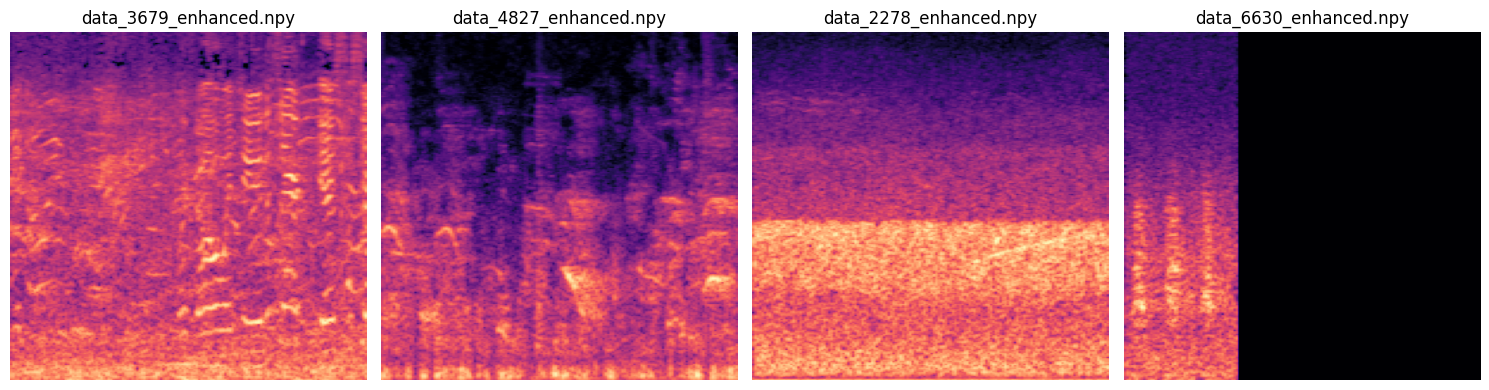

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import os
import random

def visualize_random_cached_mels(n=4):
    cached_files = [f for f in os.listdir(CACHE_DIR) if f.endswith('_enhanced.npy')]
    if len(cached_files) == 0:
        print(" No cached mel spectrograms found.")
        return

    selected_files = random.sample(cached_files, min(n, len(cached_files)))

    plt.figure(figsize=(15, 4))
    for i, fname in enumerate(selected_files):
        mel = np.load(os.path.join(CACHE_DIR, fname))

        # Squeeze last dimension to get (128, time) for plotting
        mel = np.squeeze(mel, axis=-1)

        plt.subplot(1, n, i + 1)
        plt.imshow(mel, origin='lower', aspect='auto', cmap='magma')
        plt.title(fname)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run it
visualize_random_cached_mels()


# Convert .npy to .tfrecord

In [5]:
import os
import numpy as np
import tensorflow as tf
from tqdm import tqdm

def convert_cached_npy_to_tfrecord(file_paths, labels, tfrecord_path):
    """
    Converts cached .npy mel spectrograms to a single .tfrecord file.
    Adds index information for K-Fold filtering later.
    Skips conversion if the .tfrecord file already exists.
    """
    os.makedirs(os.path.dirname(tfrecord_path), exist_ok=True)

    if os.path.exists(tfrecord_path):
        print(f"[SKIP] TFRecord already exists: {tfrecord_path}")
        return

    print(f"[INFO] Converting {len(file_paths)} .npy cached files to TFRecord with index...")

    def _serialize_example(mel, label, index):
        feature = {
            "mel": tf.train.Feature(bytes_list=tf.train.BytesList(value=[mel.tobytes()])),
            "label": tf.train.Feature(int64_list=tf.train.Int64List(value=[label])),
            "index": tf.train.Feature(int64_list=tf.train.Int64List(value=[index]))
        }
        example = tf.train.Example(features=tf.train.Features(feature=feature))
        return example.SerializeToString()

    with tf.io.TFRecordWriter(tfrecord_path) as writer:
        for index, (path, label) in tqdm(enumerate(zip(file_paths, labels)), total=len(file_paths), desc="Writing TFRecord"):
            try:
                npy_path = os.path.join(
                    CACHE_DIR, os.path.basename(path).replace('.wav', '_enhanced.npy')
                )
                mel = np.load(npy_path)

                assert mel.shape == (N_MELS, FIXED_TIME_STEPS, 1), f"Bad shape: {npy_path}"
                serialized = _serialize_example(mel, label, index)
                writer.write(serialized)

            except Exception as e:
                print(f"[ERROR] Failed to process {path}: {e}")

    print(f"[DONE] Saved TFRecord to: {tfrecord_path}")


# Binary Classification Model Data Paths

In [6]:
def get_binary_class_dataset(file_paths, labels, class_a=5, class_b=7, shuffle=True):
    binary_paths = []
    binary_labels = []

    for path, label in zip(file_paths, labels):
        if label == class_a:
            binary_paths.append(path)
            binary_labels.append(1)
        elif label == class_b:
            binary_paths.append(path)
            binary_labels.append(0)

    binary_paths = np.array(binary_paths)
    binary_labels = np.array(binary_labels)

    if shuffle:
        idx = np.random.permutation(len(binary_paths))
        binary_paths = binary_paths[idx]
        binary_labels = binary_labels[idx]

    print(f" Binary dataset created: {len(binary_paths)} samples (1s: {np.sum(binary_labels)}, 0s: {np.sum(binary_labels == 0)})")

    return binary_paths, binary_labels


In [ ]:
# TensorFlow-optimized augmentation function
@tf.function
def tf_augment_spectrogram(spectrogram):
    """
    GPU-accelerated augmentation function that supports both [H, W, C] and [B, H, W, C].
    It explicitly enforces shape to avoid TensorFlow shape inference errors.
    """
    input_rank = tf.rank(spectrogram)

    def _augment_single(x):
        # === Enforce known static shape ===
        x = tf.ensure_shape(x, [N_MELS, FIXED_TIME_STEPS, 1])
        height = N_MELS
        width = FIXED_TIME_STEPS
        channels = 1

        # === Time Stretch ===
        stretch_factor = tf.random.uniform([], 0.8, 1.2)
        new_width = tf.cast(tf.cast(width, tf.float32) * stretch_factor, tf.int32)
        x = tf.image.resize(x, [height, new_width])
        x = tf.image.resize(x, [height, width])

        # === Frequency Mask ===
        freq_mask_param = tf.cast(tf.cast(height, tf.float32) * 0.15, tf.int32)
        f0 = tf.random.uniform([], 0, height - freq_mask_param, dtype=tf.int32)
        freq_mask = tf.ones((freq_mask_param, width, channels), dtype=tf.float32)
        freq_pad = [[f0, height - f0 - freq_mask_param], [0, 0], [0, 0]]
        freq_mask = tf.pad(freq_mask, freq_pad, constant_values=0.0)
        x = x * (1.0 - freq_mask)

        # === Time Mask ===
        time_mask_param = tf.cast(tf.cast(width, tf.float32) * 0.15, tf.int32)
        t0 = tf.random.uniform([], 0, width - time_mask_param, dtype=tf.int32)
        time_mask = tf.ones((height, time_mask_param, channels), dtype=tf.float32)
        time_pad = [[0, 0], [t0, width - t0 - time_mask_param], [0, 0]]
        time_mask = tf.pad(time_mask, time_pad, constant_values=0.0)
        x = x * (1.0 - time_mask)

        # === Gaussian Noise ===
        noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=0.01)
        x = x + noise

        # === Frequency Shift ===
        shift_steps = tf.random.uniform([], -5, 5, dtype=tf.int32)
        should_shift = tf.random.uniform([], 0, 1) < 0.5

        def shift_tensor():
            return tf.cond(
                shift_steps > 0,
                lambda: tf.concat([
                    x[shift_steps:, :, :],
                    tf.zeros((shift_steps, width, channels), dtype=x.dtype)
                ], axis=0),
                lambda: tf.cond(
                    shift_steps < 0,
                    lambda: tf.concat([
                        tf.zeros((-shift_steps, width, channels), dtype=x.dtype),
                        x[:height + shift_steps, :, :]
                    ], axis=0),
                    lambda: x
                )
            )

        x = tf.cond(should_shift, shift_tensor, lambda: x)

        # === Normalize ===
        x_min = tf.reduce_min(x)
        x_max = tf.reduce_max(x)
        x = (x - x_min) / (x_max - x_min + 1e-6)

        return x

    # Handle both single and batch inputs
    return tf.cond(
        input_rank == 4,
        lambda: tf.map_fn(_augment_single, spectrogram),
        lambda: _augment_single(spectrogram)
    )





def create_hybrid_dataset(tfrecord_path, batch_size=32, augment=True, include_indices=None):
    """
    Load mel + label + index from TFRecord, with optional filtering for K-Fold subsets.
    """

    feature_description = {
        "mel": tf.io.FixedLenFeature([], tf.string),
        "label": tf.io.FixedLenFeature([], tf.int64),
        "index": tf.io.FixedLenFeature([], tf.int64),
    }

    def _parse_example(example_proto):
        parsed = tf.io.parse_single_example(example_proto, feature_description)
        mel_raw = tf.io.decode_raw(parsed["mel"], tf.float32)
        mel = tf.reshape(mel_raw, [N_MELS, FIXED_TIME_STEPS, 1])
        label = tf.cast(parsed["label"], tf.int32)
        index = tf.cast(parsed["index"], tf.int32)
        return mel, label, index

    dataset = tf.data.TFRecordDataset(tfrecord_path)
    dataset = dataset.map(_parse_example, num_parallel_calls=tf.data.AUTOTUNE)

    if include_indices is not None:
        include_indices = tf.constant(list(include_indices), dtype=tf.int32)
        def _filter_by_index(mel, label, index):
            return tf.reduce_any(tf.equal(index, include_indices))
        dataset = dataset.filter(_filter_by_index)

    # Drop index for downstream
    dataset = dataset.map(lambda mel, label, index: (mel, label), num_parallel_calls=tf.data.AUTOTUNE)

    # Guarantee correct shape
    dataset = dataset.map(
        lambda x, y: (tf.ensure_shape(x, [N_MELS, FIXED_TIME_STEPS, 1]), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if augment:
        dataset = dataset.map(
            lambda x, y: (
                tf.cond(
                    tf.random.uniform([], 0, 1) < 0.7,
                    lambda: tf_augment_spectrogram(x),
                    lambda: x
                ),
                y
            ),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    dataset = dataset.cache().shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset


# Validating conversions and data loading etc.

In [12]:
# Test dataset split & augmentation 

# Simulate binary classification subset
binary_paths, binary_labels = get_binary_class_dataset(file_paths, labels)

# Assign dummy indices (just 0 to N-1 for now)
dummy_indices = np.arange(len(binary_paths))
TFRECORD_TEST_PATH = os.path.join("dataset/tfrecords", "binary_test.tfrecord")

# Convert to TFRecord with index support
def convert_cached_npy_to_tfrecord_with_index(file_paths, labels, indices, tfrecord_path):
    os.makedirs(os.path.dirname(tfrecord_path), exist_ok=True)

    def _serialize_example(mel, label, index):
        feature = {
            "mel": tf.train.Feature(bytes_list=tf.train.BytesList(value=[mel.tobytes()])),
            "label": tf.train.Feature(int64_list=tf.train.Int64List(value=[label])),
            "index": tf.train.Feature(int64_list=tf.train.Int64List(value=[index]))
        }
        example = tf.train.Example(features=tf.train.Features(feature=feature))
        return example.SerializeToString()

    with tf.io.TFRecordWriter(tfrecord_path) as writer:
        for path, label, index in tqdm(zip(file_paths, labels, indices), total=len(file_paths), desc="Writing TFRecord"):
            try:
                npy_path = os.path.join(CACHE_DIR, os.path.basename(path).replace('.wav', '_enhanced.npy'))
                mel = np.load(npy_path)
                assert mel.shape == (N_MELS, FIXED_TIME_STEPS, 1)
                serialized = _serialize_example(mel, label, index)
                writer.write(serialized)
            except Exception as e:
                print(f"[ERROR] Skipping {path}: {e}")

# Run conversion (once)
convert_cached_npy_to_tfrecord_with_index(binary_paths, binary_labels, dummy_indices, TFRECORD_TEST_PATH)

# Split indices
split = int(0.8 * len(dummy_indices))
train_idx = dummy_indices[:split]
val_idx = dummy_indices[split:]

# Load dataset splits
train_ds = create_hybrid_dataset(TFRECORD_TEST_PATH, batch_size=4, augment=True, include_indices=train_idx)
val_ds = create_hybrid_dataset(TFRECORD_TEST_PATH, batch_size=4, augment=False, include_indices=val_idx)

# Inspect a batch from both
for x_batch, y_batch in train_ds.take(1):
    print("Train batch:")
    print("  shape:", x_batch.shape)
    print("  labels:", y_batch.numpy())

for x_batch, y_batch in val_ds.take(1):
    print("Val batch:")
    print("  shape:", x_batch.shape)
    print("  labels:", y_batch.numpy())


 Binary dataset created: 1629 samples (1s: 801, 0s: 828)


Writing TFRecord: 100%|██████████| 1629/1629 [00:00<00:00, 2728.17it/s]


ValueError: in user code:

    File "C:\Users\emink\AppData\Local\Temp\ipykernel_9304\4021271600.py", line 123, in None  *
        )
    File "C:\Users\emink\AppData\Local\Temp\ipykernel_9304\4021271600.py", line 12, in _augment_single  *
        x = tf.ensure_shape(x, [N_MELS, FIXED_TIME_STEPS, 1])

    ValueError: Shape must be rank 3 but is rank 2 for '{{node cond/map/while/EnsureShape}} = EnsureShape[T=DT_FLOAT, shape=[256,150,1]](cond/map/while/TensorArrayV2Read/TensorListGetItem)' with input shapes: [150,1].


In [74]:
# === TEST: full 10-class split ===

# Dummy indices
all_indices = np.arange(len(file_paths))
TFRECORD_FULL_PATH = os.path.join("dataset/tfrecords", "full_test.tfrecord")

# Reuse the converter with index
convert_cached_npy_to_tfrecord_with_index(file_paths, labels, all_indices, TFRECORD_FULL_PATH)

# Split indices
split = int(0.8 * len(all_indices))
train_idx = all_indices[:split]
val_idx = all_indices[split:]

# Load full dataset
train_ds_full = create_hybrid_dataset(TFRECORD_FULL_PATH, batch_size=4, augment=True, include_indices=train_idx)
val_ds_full = create_hybrid_dataset(TFRECORD_FULL_PATH, batch_size=4, augment=False, include_indices=val_idx)

# Inspect
for x_batch, y_batch in train_ds_full.take(1):
    print("Full Train batch:")
    print("  shape:", x_batch.shape)
    print("  labels:", y_batch.numpy())

for x_batch, y_batch in val_ds_full.take(1):
    print("Full Val batch:")
    print("  shape:", x_batch.shape)
    print("  labels:", y_batch.numpy())


Writing TFRecord: 100%|██████████| 7057/7057 [00:31<00:00, 225.19it/s] 


Full Train batch:
  shape: (4, 256, 150, 1)
  labels: [7 2 8 1]
Full Val batch:
  shape: (4, 256, 150, 1)
  labels: [4 0 4 3]


# Focal Loss

In [87]:
def get_focal_loss(gamma=2.0, alpha=0.25):
    """
    Flexible Focal Loss for both binary and multi-class classification.
    """
    def focal_loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        
        # Binary case
        if tf.shape(y_pred)[-1] == 1:
            y_pred = tf.nn.sigmoid(y_pred)
            ce = -(y_true * tf.math.log(y_pred + 1e-7) + 
                   (1 - y_true) * tf.math.log(1 - y_pred + 1e-7))
            p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
            alpha_factor = y_true * alpha + (1 - y_true) * (1 - alpha)
            modulating_factor = tf.pow(1.0 - p_t, gamma)
            loss = alpha_factor * modulating_factor * ce

        # Multi-class case
        else:
            if tf.shape(y_true)[-1] != tf.shape(y_pred)[-1]:
                y_true = tf.one_hot(tf.cast(y_true, tf.int32), tf.shape(y_pred)[-1])
            y_pred = tf.nn.softmax(y_pred, axis=-1)
            ce = -tf.reduce_sum(y_true * tf.math.log(y_pred + 1e-7), axis=-1)
            p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
            loss = tf.pow(1.0 - p_t, gamma) * ce

        return tf.reduce_mean(loss)

    return focal_loss


# SE Funtion Used In Both Models

In [88]:
def squeeze_excite_block(input_tensor, ratio=16, dropout_rate=0.1):
    """
    Enhanced SE block with dynamic shape support and optional dropout.
    
    Args:
        input_tensor: 4D tensor (batch, height, width, channels)
        ratio: Reduction ratio
        dropout_rate: Dropout between Dense layers (optional)

    Returns:
        Tensor with channel attention applied
    """
    # Dynamic-safe way to get channel dimension
    filters = input_tensor.shape[-1]
    if filters is None:
        filters = tf.shape(input_tensor)[-1]

    # Squeeze: Global spatial information
    se = layers.GlobalAveragePooling2D()(input_tensor)
    se = layers.Reshape((1, 1, filters))(se)
    
    # Excitation: Bottleneck -> Non-linearity -> Attention
    se = layers.Dense(filters // ratio, activation='relu', kernel_initializer='he_normal')(se)
    
    # Optional: Dropout for regularization
    if dropout_rate > 0:
        se = layers.Dropout(dropout_rate)(se)
    
    se = layers.Dense(filters, activation='sigmoid', kernel_initializer='he_normal')(se)
    
    # Scale the original input
    return layers.multiply([input_tensor, se])

# Binary Model

In [89]:
def build_enhanced_binary_model(hp):
    # Keep existing hyperparameters
    lr = hp.Float("learning_rate", 1e-4, 1e-3, sampling="log")
    dropout = hp.Float("dropout", 0.3, 0.6, step=0.1)
    l2_val = hp.Float("l2", 1e-5, 1e-3, sampling="log")
    se_ratio = hp.Choice("se_ratio", [8, 16])
    se_dropout = hp.Float("se_dropout", 0.05, 0.2, step=0.05)
    
    # New hyperparameters
    filters_start = hp.Choice("filters_start", [32, 48, 64])
    depth = hp.Int("depth", 3, 5)
    use_attn = hp.Boolean("use_attention_mechanism")
    
    inputs = tf.keras.Input(shape=(N_MELS, FIXED_TIME_STEPS, 1))
    
    # Initial block with more filters
    x = layers.Conv2D(filters_start, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Dynamic number of residual blocks
    filters = filters_start
    for i in range(depth):
        # Double filters every other layer
        if i > 0 and i % 2 == 0:
            filters *= 2
            
        # Residual Block with optional skip connection adjustment
        residual = x
        if filters != x.shape[-1]:
            residual = layers.Conv2D(filters, (1, 1), padding='same')(x)
            
        x = layers.Conv2D(filters, (3, 3), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Conv2D(filters, (3, 3), padding='same')(x)
        x = layers.BatchNormalization()(x)
        
        # Add residual connection
        x = layers.add([x, residual])
        x = layers.Activation('relu')(x)
        
        # Conditional attention mechanism
        if use_attn:
            x = squeeze_excite_block(x, ratio=se_ratio, dropout_rate=se_dropout)
        
        # Apply pooling every other layer to avoid excessive downsampling
        if i < depth - 1 and i % 2 == 0:
            x = layers.MaxPooling2D((2, 2))(x)
    
    # Additional feature extraction paths (multi-scale analysis)
    # Global average pooling path
    gap = layers.GlobalAveragePooling2D()(x)
    
    # Global max pooling path
    gmp = layers.GlobalMaxPooling2D()(x)
    
    # Combine features
    combined = layers.Concatenate()([gap, gmp])
    
    # Head with deeper layers
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2_val))(combined)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(l2_val))(x)
    x = layers.Dropout(dropout/2)(x)
    
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(), tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model

# Binary Hyperparameter Tune

In [90]:
def run_binary_hyperparameter_tuning(tfrecord_path):
    """
    Run hyperparameter tuning for binary classification using TFRecord.
    Automatically splits data and applies augmentation only on training.
    """
    TUNER_DIR = "tuner_results_binary"

    # === Load full dataset once ===
    full_ds = create_hybrid_dataset(tfrecord_path, batch_size=1, augment=False)  # No augment yet

    # === Count total examples ===
    total_samples = sum(1 for _ in full_ds)
    val_size = int(0.2 * total_samples)

    # === Resplit with augmentation ===
    # Reload because dataset iterators are one-shot
    full_ds = create_hybrid_dataset(tfrecord_path, batch_size=1, augment=False)

    train_raw = full_ds.skip(val_size)
    val_raw = full_ds.take(val_size)

    # Re-apply augmentation on train only
    train_ds = train_raw.map(
        lambda x, y: (tf_augment_spectrogram(x), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # === Final formatting ===
    train_ds = train_ds.cache().shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    val_ds = val_raw.cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # === Tuner setup ===
    tuner = kt.Hyperband(
        build_enhanced_binary_model,
        objective='val_accuracy',
        max_epochs=20,
        factor=3,
        hyperband_iterations=3,
        directory=TUNER_DIR,
        project_name='binary_cnn_finetune',
        overwrite=False,
        seed=SEED
    )

    # === Callbacks ===
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True
    )
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )

    # === Run tuning ===
    tuner.search(
        train_ds,
        validation_data=val_ds,
        epochs=20,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    # === Return best HP ===
    best_hp = tuner.get_best_hyperparameters(1)[0]
    print("\nBest Hyperparameters for Binary Model:")
    for param in best_hp.values:
        print(f"{param}: {best_hp.get(param)}")

    return best_hp


# Binary Model Train

In [91]:
def train_enhanced_binary_model(best_hp, binary_file_paths, binary_labels, tfrecord_path):
    """
    Train binary classification model using TFRecord and save only the best-performing fold.
    """
    BINARY_MODEL_PATH = "binary_model/binary_classifier_best.keras"
    os.makedirs(os.path.dirname(BINARY_MODEL_PATH), exist_ok=True)

    # === Load full dataset ===
    full_ds = create_hybrid_dataset(tfrecord_path, batch_size=1, augment=False)
    all_data = list(full_ds)  # Warning: Only do this if dataset fits in RAM

    mels = [x[0] for x in all_data]
    lbls = [x[1].numpy() for x in all_data]

    mels = tf.stack(mels)
    lbls = np.array(lbls)

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    fold_models = []
    fold_val_accuracies = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(mels, lbls)):
        print(f"\n===== Training Binary Model: Fold {fold+1}/5 =====")

        # === Split ===
        x_train, y_train = tf.gather(mels, train_idx), lbls[train_idx]
        x_val, y_val = tf.gather(mels, val_idx), lbls[val_idx]

        train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
        val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))

        # === Augment Train ===
        train_ds = train_ds.map(
            lambda x, y: (tf_augment_spectrogram(x), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )

        # === Batch + cache ===
        train_ds = train_ds.cache().shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
        val_ds = val_ds.cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

        # === Class weights ===
        class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

        # === Model ===
        model = build_enhanced_binary_model(best_hp)

        callbacks = [
            EarlyStopping(monitor='val_auc', patience=15, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_auc', patience=7, factor=0.5, min_lr=1e-6, verbose=1)
        ]

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=best_hp.get('learning_rate')),
            loss=get_focal_loss(gamma=2.0, alpha=0.25),
            metrics=['accuracy', tf.keras.metrics.AUC(), tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
        )

        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS + 10,
            class_weight=class_weight_dict,
            callbacks=callbacks,
            verbose=1
        )

        fold_models.append(model)
        best_val_acc = max(history.history['val_accuracy'])
        fold_val_accuracies.append(best_val_acc)
        print(f"Fold {fold+1} Best Validation Accuracy: {best_val_acc:.4f}")

    # === Save best fold ===
    best_model = fold_models[np.argmax(fold_val_accuracies)]
    tf.keras.models.save_model(best_model, BINARY_MODEL_PATH)
    print(f"\n Best fold model saved to: {BINARY_MODEL_PATH}")

    return best_model


# Run Binary Model tuning-training

In [92]:
#  Prepare Binary Dataset from Original Labels 
binary_file_paths, binary_labels = get_binary_class_dataset(file_paths, labels)

# Convert NPY to TFRecord (only once) 
BINARY_TFRECORD_PATH = "dataset/tfrecords/binary_all.tfrecord"
convert_cached_npy_to_tfrecord(binary_file_paths, binary_labels, BINARY_TFRECORD_PATH)

 Binary dataset created: 1629 samples (1s: 801, 0s: 828)
[SKIP] TFRecord already exists: dataset/tfrecords/binary_all.tfrecord


In [93]:
# tune
binary_best_hp = run_binary_hyperparameter_tuning(BINARY_TFRECORD_PATH)

ValueError: in user code:

    File "C:\Users\emink\AppData\Local\Temp\ipykernel_2660\4177095945.py", line 24, in None  *
        lambda x, y: (tf_augment_spectrogram(x), y)
    File "C:\Users\emink\AppData\Local\Temp\ipykernel_2660\250156885.py", line 45, in shift_tensor  *
        lambda: tf.cond(

    ValueError: Shape must be rank 4 but is rank 3 for '{{node cond/cond/concat}} = ConcatV2[N=2, T=DT_FLOAT, Tidx=DT_INT32](cond/cond/strided_slice, cond/cond/zeros, cond/cond/concat/axis)' with input shapes: [?,?,256,150], [?,?,?], [].


In [ ]:
#Train Best Model Using Stratified K-Fold 
binary_model = train_enhanced_binary_model(
    best_hp=binary_best_hp,
    binary_file_paths=binary_file_paths,
    binary_labels=binary_labels,
    tfrecord_path=BINARY_TFRECORD_PATH
)

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.7010 - loss: 0.7143
Epoch 1: val_accuracy improved from -inf to 0.50920, saving model to /kaggle/working/binary_model/binary_classifier_best.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 30s 325ms/step - accuracy: 0.7018 - loss: 0.7127 - val_accuracy: 0.5092 - val_loss: 0.7605 - learning_rate: 2.2517e-04
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7618 - loss: 0.5700
Epoch 2: val_accuracy did not improve from 0.50920
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.7626 - loss: 0.5690 - val_accuracy: 0.5092 - val_loss: 0.7576 - learning_rate: 2.2517e-04
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8192 - loss: 0.4340
Epoch 3: val_accuracy improved from 0.50920 to 0.64417, saving model to /kaggle/working/binary_model/binary_classifier_best.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.8197 - loss: 0.4337 - val_accuracy: 0.6442 - val_loss: 0.7552 - learning_rate: 2.2517e-04
Ep

#  Main Model

In [13]:

def build_model(hp):
    lr = hp.Float("learning_rate", 1e-4, 1e-3, sampling="log")
    dropout = hp.Float("dropout", 0.3, 0.6, step=0.1)
    l2_val = hp.Float("l2", 1e-5, 1e-3, sampling="log")
    
    # tunable hyperparams for attention
    se_ratio = hp.Choice("se_ratio", [8, 16])
    se_dropout = hp.Float("se_dropout", 0.05, 0.2, step=0.05)

    inputs = tf.keras.layers.Input(shape=(N_MELS, FIXED_TIME_STEPS, 1))

    # Initial block
    x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Residual Block 1
    residual = x
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.add([x, residual])
    x = layers.Activation('relu')(x)
    x = squeeze_excite_block(x, ratio=se_ratio, dropout_rate=se_dropout)
    x = layers.MaxPooling2D((2, 2))(x)

    # Residual Block 2
    residual = layers.Conv2D(64, (1, 1), padding='same')(x)
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.add([x, residual])
    x = layers.Activation('relu')(x)
    x = squeeze_excite_block(x, ratio=se_ratio, dropout_rate=se_dropout)
    x = layers.MaxPooling2D((2, 2))(x)

    # Residual Block 3
    residual = layers.Conv2D(128, (1, 1), padding='same')(x)
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.add([x, residual])
    x = layers.Activation('relu')(x)
    x = squeeze_excite_block(x, ratio=se_ratio, dropout_rate=se_dropout)
    x = layers.MaxPooling2D((2, 2))(x)

    # Final Dense Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2_val))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [ ]:
# Dummy hyperparams to test
#from keras_tuner.engine.hyperparameters import HyperParameters

#hp = HyperParameters()
#hp.values = {
#    "learning_rate": 1e-4,
#    "dropout": 0.4,
#    "l2": 1e-4,
#    "se_ratio": 8,
#    "se_dropout": 0.1
#}

#model = build_model(hp)
#model.summary()

# Main Model Tuner

In [ ]:
def run_hyperparameter_tuning(tfrecord_path):
    """
    Run hyperparameter tuning for the main (10-class) classification model using TFRecord.
    Applies augmentation only on training portion.
    """
    TUNER_DIR = "tuner_results"

    # === Load full dataset ===
    full_ds = create_hybrid_dataset(tfrecord_path, batch_size=1, augment=False)  # no augment yet

    # === Count samples ===
    total_samples = sum(1 for _ in full_ds)
    val_size = int(0.2 * total_samples)

    # === Re-load dataset and split ===
    full_ds = create_hybrid_dataset(tfrecord_path, batch_size=1, augment=False)

    val_raw = full_ds.take(val_size)
    train_raw = full_ds.skip(val_size)

    # === Apply augmentation to training ===
    train_ds = train_raw.map(
        lambda x, y: (tf_augment_spectrogram(x), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # === Final formatting ===
    train_ds = train_ds.cache().shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    val_ds = val_raw.cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # === Tuner setup ===
    tuner = kt.Hyperband(
        build_model,
        objective='val_accuracy',
        max_epochs=20,
        factor=3,
        hyperband_iterations=2,
        directory=TUNER_DIR,
        project_name='mel_cnn_finetune',
        overwrite=False,
        seed=SEED
    )

    # === Callbacks ===
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True
    )
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )

    # === Run Tuning ===
    tuner.search(
        train_ds,
        validation_data=val_ds,
        epochs=20,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    # === Return best HP ===
    best_hp = tuner.get_best_hyperparameters(1)[0]
    print("\nBest Hyperparameters Found:")
    for param in best_hp.values:
        print(f"{param}: {best_hp.get(param)}")

    return best_hp


# Train

In [ ]:
def train_kfold(best_hp, tfrecord_path):
    """Train with K-Fold using cached TFRecord and enhanced performance pipeline."""
    MODEL_DIR = os.path.join(os.getcwd(), "model")
    os.makedirs(MODEL_DIR, exist_ok=True)

    # === Load full dataset (once) ===
    full_ds = create_hybrid_dataset(tfrecord_path, batch_size=1, augment=False)
    all_data = list(full_ds)  # Only safe if dataset fits in RAM

    mels = [x[0] for x in all_data]
    lbls = [x[1].numpy() for x in all_data]

    mels = tf.stack(mels)
    lbls = np.array(lbls)

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(mels, lbls)):
        print(f"\n===== Training Main Model: Fold {fold+1}/{N_FOLDS} =====")

        x_train, y_train = tf.gather(mels, train_idx), lbls[train_idx]
        x_val, y_val = tf.gather(mels, val_idx), lbls[val_idx]

        train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
        val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))

        # === Augment train only ===
        train_ds = train_ds.map(
            lambda x, y: (tf_augment_spectrogram(x), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )

        # === Format datasets ===
        train_ds = train_ds.cache().shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
        val_ds = val_ds.cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

        # === Class weights ===
        class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

        # === Build + Compile model ===
        model = build_model(best_hp)
        model_path = f"model/fold_{fold + 1}_best_model.keras"

        callbacks = [
            EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_accuracy', patience=5, factor=0.5, min_lr=1e-5, verbose=1),
            ModelCheckpoint(model_path, monitor='val_accuracy', save_best_only=True, verbose=1)
        ]

        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS,
            class_weight=class_weight_dict,
            callbacks=callbacks,
            verbose=1
        )

        best_val_acc = max(history.history['val_accuracy'])
        best_val_loss = min(history.history['val_loss'])

        print(f" Fold {fold + 1}: Best Val Accuracy = {best_val_acc:.4f}, Loss = {best_val_loss:.4f}")
        fold_results.append({
            "fold": fold + 1,
            "val_accuracy": best_val_acc,
            "val_loss": best_val_loss,
            "model_path": model_path
        })

    return fold_results


# Calling Tuning and Training

In [ ]:
#Ensure TFRecord is created first (only once)
MAIN_TFRECORD_PATH = "dataset/tfrecords/all.tfrecord"
convert_cached_npy_to_tfrecord(file_paths, labels, MAIN_TFRECORD_PATH)

In [ ]:
# Run tuning
main_best_hp = run_hyperparameter_tuning(MAIN_TFRECORD_PATH)

In [ ]:
# Run K-Fold training
main_fold_results = train_kfold(main_best_hp, MAIN_TFRECORD_PATH)

# Test


---

### **Testing Pipeline Overview**

1. **Load Test Data**  
   Test audio files and labels are loaded, and mel spectrograms are cached (if not already).

2. **Model Ensemble Prediction**  
   - Each of the 5 fold models predicts the test set.  
   - Their predictions are combined via **majority voting** to get the **ensemble prediction**.

3. **Binary Classifier Patch** *(for class 5 vs 7 confusion)*  
   - From the ensemble, samples predicted as **class 7** are passed to a **binary classifier**.
   - If the binary model predicts **class 5**, the ensemble prediction is overridden to 5.

4. **Final Evaluation**  
   - Accuracy and classification report are computed **before and after** patching.
   - The pipeline compares **best single model**, **ensemble**, and **patched results**.

---



## TODO:

## Optimization Ideas

1. **Confidence-Based Patching**:
   - Consider only patching predictions where the ensemble is less confident (e.g., probability < 0.8)
   - This could prevent "correcting" high-confidence correct predictions

2. **Binary Model Threshold Tuning**:
   - You could find the optimal threshold for your binary classifier using ROC analysis
   - A simple validation set could help tune this threshold parameter

3. **Error Analysis Visualization**:
   - Consider adding confusion matrix visualization
   - Potentially include sample-level inspection of examples where patching changes the prediction

4. **Potential Weight Adjustments**:
   - Weight fold models by their validation performance when averaging probabilities
   - This could give more influence to better-performing models

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
import numpy as np
import pandas as pd
import os
import librosa

# ========== Paths ==========
TEST_CACHE_DIR = "dataset/test_mel_cache"
BINARY_MODEL_PATH = "binary_model/binary_classifier_best.keras"
MODEL_DIR = "model"

# ========== Create Cache Directory ==========
os.makedirs(TEST_CACHE_DIR, exist_ok=True)

# ========== Load Test Data ==========
test_df = pd.read_csv(TEST_CSV_PATH)
test_df["filepath"] = test_df["file_name"].apply(lambda x: os.path.join(TEST_AUDIO_DIR, x))
test_paths = test_df["filepath"].values
test_labels = test_df["classID"].values

# ========== Audio Loader ==========
def load_and_cache_audio_test(file_path):
    cache_file = os.path.join(TEST_CACHE_DIR, os.path.basename(file_path).replace('.wav', '_enhanced.npy'))
    if os.path.exists(cache_file):
        try:
            return np.load(cache_file)
        except:
            pass
    try:
        y, sr = librosa.load(file_path, sr=SR)
        y_harmonic, y_percussive = librosa.effects.hpss(y)
        mel_h = librosa.feature.melspectrogram(y=y_harmonic, sr=sr, n_mels=N_MELS, fmax=FMAX)
        mel_p = librosa.feature.melspectrogram(y=y_percussive, sr=sr, n_mels=N_MELS, fmax=FMAX)
        mel_h_db = librosa.power_to_db(mel_h, ref=np.max)
        mel_p_db = librosa.power_to_db(mel_p, ref=np.max)
        mel_db = 0.4 * mel_h_db + 0.6 * mel_p_db
        mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
        mel_db = np.expand_dims(mel_db, axis=-1)
        np.save(cache_file, mel_db)
        return mel_db
    except:
        return np.zeros((N_MELS, FIXED_TIME_STEPS, 1), dtype=np.float32)

# ========== TF Dataset Builder ==========
def create_test_dataset(file_paths, labels, batch_size=32):
    def process_path(file_path, label):
        def _load(path):
            path = path.numpy().decode("utf-8")
            mel = load_and_cache_audio_test(path)
            if mel.shape[1] != FIXED_TIME_STEPS:
                mel = librosa.util.fix_length(np.squeeze(mel, axis=-1), FIXED_TIME_STEPS, axis=1)
                mel = np.expand_dims(mel, axis=-1)
            elif mel.ndim == 2:
                mel = np.expand_dims(mel, axis=-1)
            return mel.astype(np.float32)
        mel = tf.py_function(_load, inp=[file_path], Tout=tf.float32)
        mel = tf.ensure_shape(mel, [N_MELS, FIXED_TIME_STEPS, 1])
        return mel, tf.cast(label, tf.int32)
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    ds = ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# ========== Load Binary Classifier ==========
binary_model = tf.keras.models.load_model(BINARY_MODEL_PATH)

def patch_predictions(preds, file_paths, threshold=0.5):
    idx_7 = np.where(preds == 7)[0]
    if len(idx_7) == 0:
        return preds
    patch_ds = create_test_dataset(file_paths[idx_7], np.zeros(len(idx_7)))
    probs = binary_model.predict(patch_ds, verbose=0).squeeze()
    binary_preds = (probs >= threshold).astype(int)
    patched = preds.copy()
    patched[idx_7[binary_preds == 1]] = 5
    return patched

# ========== Load Fold Models and Predict ==========
model_paths = sorted([
    os.path.join(MODEL_DIR, f) for f in os.listdir(MODEL_DIR)
    if f.endswith(".keras") and f.startswith("fold_")
])

print("\n Evaluating models...\n")
soft_preds = []
hard_preds = []
patched_hard_preds = []
patched_soft_preds = []
accuracies = []

test_ds = create_test_dataset(test_paths, test_labels)

for i, model_path in enumerate(model_paths):
    print(f"→ Loading model: {model_path}")
    model = tf.keras.models.load_model(model_path)
    probs = model.predict(test_ds, verbose=0)
    
    # Hard prediction
    hard = np.argmax(probs, axis=1)
    acc = accuracy_score(test_labels, hard)
    accuracies.append(acc)
    hard_preds.append(hard)

    # Patch hard preds
    patched = patch_predictions(hard, test_paths)
    patched_hard_preds.append(patched)

    # Store soft preds
    soft_preds.append(probs)

    print(f"   Fold Accuracy: {acc:.4f}")

# ========== Ensemble Voting ==========
soft_preds = np.stack(soft_preds)  # (n_models, n_samples, n_classes)
avg_probs = np.mean(soft_preds, axis=0)  # (n_samples, n_classes)
ensemble_preds = np.argmax(avg_probs, axis=1)
ensemble_acc = accuracy_score(test_labels, ensemble_preds)

print("\n Ensemble Classification Report:")
print(classification_report(test_labels, ensemble_preds, digits=4))
print(f"Ensemble Accuracy: {ensemble_acc:.4f}")

# ========== Patched Ensemble ==========
patched_ensemble_preds = patch_predictions(ensemble_preds, test_paths)
patched_acc = accuracy_score(test_labels, patched_ensemble_preds)

print("\n Patched Ensemble Classification Report:")
print(classification_report(test_labels, patched_ensemble_preds, digits=4))
print(f"Patched Ensemble Accuracy: {patched_acc:.4f}")

# ========== Individual Fold Comparisons ==========
print("\n === Individual Fold Summaries ===\n")
for i, (raw, patched, acc) in enumerate(zip(hard_preds, patched_hard_preds, accuracies)):
    patched_acc = accuracy_score(test_labels, patched)
    print(f"Fold {i+1}:")
    print(f"  Raw    Accuracy: {acc:.4f}")
    print(f"  Patched Accuracy: {patched_acc:.4f}")
    print("")

# ========== Summary: Best Accuracy Across All Predictions ==========
all_results = {
    "Ensemble": ensemble_preds,
    "Patched Ensemble": patched_ensemble_preds,
}

# Add folds and patched folds
for i, preds in enumerate(hard_preds):
    all_results[f"Fold {i+1}"] = preds
for i, preds in enumerate(patched_hard_preds):
    all_results[f"Fold {i+1} (Patched)"] = preds

# Find best
best_name = None
best_acc = -1
best_preds = None

for name, preds in all_results.items():
    acc = accuracy_score(test_labels, preds)
    if acc > best_acc:
        best_acc = acc
        best_name = name
        best_preds = preds

print(f"\n Best Result: {best_name}")
print(f"Accuracy: {best_acc:.4f}")
print("Classification Report:")
print(classification_report(test_labels, best_preds, digits=4))


### Test With Google Drive  **update requaired

In [ ]:
"""
Tarık Buğra Ay - 042101100
"""

import os
import io
import zipfile
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
import gdown
from tqdm import tqdm
from sklearn.metrics import classification_report, accuracy_score

# ========== CONFIG ==========
MODEL_ZIP_URL = "https://drive.google.com/uc?export=download&id=1f3Mh5HiuIcuACEgqY9qcbYg9WyopmJWY"
TEST_CSV_PATH = "/kaggle/input/yldz-teknik-proje-1-train-dataset/Test_Public.csv"
TEST_AUDIO_DIR = "/kaggle/input/yldz-teknik-proje-1-train-dataset/Test_Public/"
SR = 22050
N_MELS = 128
FMAX = 8000
FIXED_TIME_STEPS = 150
BATCH_SIZE = 32
EXTRACT_DIR = "/kaggle/working/extracted_models"
# ============================

# Step 1: Download and extract ZIP
print(" Downloading model ZIP from Google Drive...")
zip_path = "models.zip"
gdown.download(MODEL_ZIP_URL, zip_path, quiet=False)

print(" Extracting models from ZIP...")
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

# Step 2: Load all .keras models
models = []
model_filenames = sorted([
    f for f in os.listdir(EXTRACT_DIR)
    if f.endswith(".keras") and f.startswith("fold_")
])

print(f" Found {len(model_filenames)} models: {model_filenames}\n")

for name in model_filenames:
    model_path = os.path.join(EXTRACT_DIR, name)
    print(f"→ Loading model: {model_path}")
    model = tf.keras.models.load_model(model_path)
    models.append(model)

# Step 3: Load and process test dataset
print("\n Loading and preprocessing test set...")
df = pd.read_csv(TEST_CSV_PATH)
file_paths = [os.path.join(TEST_AUDIO_DIR, fname) for fname in df["file_name"]]
true_labels = df["classID"].values

def preprocess_audio(file_path):
    try:
        y, sr = librosa.load(file_path, sr=SR)
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, fmax=FMAX)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
        mel_db = np.expand_dims(mel_db, axis=-1)

        if mel_db.shape[1] != FIXED_TIME_STEPS:
            mel_db = librosa.util.fix_length(mel_db.squeeze(), size=FIXED_TIME_STEPS, axis=1)
            mel_db = np.expand_dims(mel_db, axis=-1)

        return mel_db.astype(np.float32)
    except Exception as e:
        print(f"[ERROR] Could not process {file_path}: {e}")
        return np.zeros((N_MELS, FIXED_TIME_STEPS, 1), dtype=np.float32)

X_test = np.stack([preprocess_audio(p) for p in tqdm(file_paths)])
y_test = np.array(true_labels)

# Step 4: Evaluate each model
print("\n Evaluating models...\n")
model_preds = []
accuracies = []

for i, model in enumerate(models):
    print(f"→ Evaluating Model {i+1}/{len(models)}")
    probs = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
    preds = np.argmax(probs, axis=1)

    acc = accuracy_score(y_test, preds)
    model_preds.append(preds)
    accuracies.append(acc)

    print(f"   Accuracy: {acc:.4f}")

# Step 5: Ensemble prediction
print("\nPerforming ensemble prediction (majority vote)...")
model_preds = np.stack(model_preds)  # Shape: (n_models, n_samples)
ensemble_preds = np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=0, arr=model_preds)
ensemble_acc = accuracy_score(y_test, ensemble_preds)

# Step 6: Report
print(f"\nEnsemble Accuracy: {ensemble_acc:.4f}")
print("\nClassification Report (Ensemble):")
print(classification_report(y_test, ensemble_preds, digits=4))

# Step 7: Best model info
best_model_idx = np.argmax(accuracies)
print("\n Best Single Model:")
print(f"   Model File : {model_filenames[best_model_idx]}")
print(f"   Accuracy   : {accuracies[best_model_idx]:.4f}")

if ensemble_acc > accuracies[best_model_idx]:
    print("Ensemble outperformed the best individual model.")
else:
    print("Best individual model outperformed the ensemble.")

# Clean up ZIP file
if os.path.exists(zip_path):
    os.remove(zip_path)


# Investigating

In [ ]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print("\nClass 5 sample count in each fold:")

for fold, (train_idx, val_idx) in enumerate(skf.split(file_paths, labels)):
    train_labels_fold = labels[train_idx]
    count_class_5 = np.sum(train_labels_fold == 5)
    print(f"Fold {fold+1}: {count_class_5} samples in training")


In [ ]:
# Show predictions for class 5
print("\n Class 5 Test Sample Predictions:")
class_5_indices = np.where(y_test == 5)[0]

for i in class_5_indices:
    fname = os.path.basename(file_paths[i])
    pred = ensemble_preds[i]
    print(f"{fname:20} | Predicted: {pred}")


In [ ]:
import IPython.display as ipd
import random

def play_random_class_audios(class_id, n=4):
    """Play n random audio files from a given class."""
    class_df = df[df["classID"] == class_id]
    if len(class_df) == 0:
        print(f"No samples found for class {class_id}")
        return

    selected = class_df.sample(n=min(n, len(class_df)), random_state=np.random.randint(0, 10000))
    
    for i, row in enumerate(selected.itertuples()):
        print(f"\n Playing Class {class_id} - {os.path.basename(row.filepath)}")
        audio, _ = librosa.load(row.filepath, sr=SR)
        ipd.display(ipd.Audio(audio, rate=SR))


In [ ]:
play_random_class_audios(5)


In [ ]:
play_random_class_audios(7)
